In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix,classification_report,precision_recall_curve,roc_auc_score,roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
data=pd.read_csv('customer_churn.csv')
df=data.copy()

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,$29.85,$29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed Check,$56.95,$1889.5,NO
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,$53.85,$108.15,YES
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,bank transfer (automatic),$42.3,$1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,$70.7,$nan,yes


In [4]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
12050,Female,0,No,No,6.0,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,$89.5,$573.3,Yes
12051,Female,0,Yes,Yes,1.0,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic Check,$74.7,$nan,Yes
12052,Male,0,No,No,72.0,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),$113.4,$8164.1,No
12053,Female,0,Yes,No,57.0,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic Check,$99.65,$5497.05,No
12054,Female,0,Yes,No,NaN,Yes,No,Fiber optic,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Mailed Check,$100.05,$6034.85,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  int64  
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,12055.0,0.117959,0.322573,0.0,0.0,0.0,0.0,1.0
tenure,11451.0,31.237796,25.027111,-3.0,6.0,28.0,54.0,74.0


In [7]:
df['tenure'].unique()

array([ 1., 34.,  2., 45.,  8., 22., 10., 28., 62., 13., 16., 58., 49.,
       25., 69., 52., 71., 21., nan, 12., 30., 72., 17., 27.,  5., 46.,
       11., 70., 63., 43., 15., 60., 18., 66., 47.,  9.,  3., 31., 50.,
       64., 56.,  7., 42., 35., 48., 29., 65., 38., 68., 32., 55., 37.,
       36., 41.,  6.,  4., 33., 67., 23., 57., 61., 14., 20., 53., 40.,
       59., 24., 44., 19., 54., 51., 26.,  0., 39., -1., 73., -2., 74.,
       -3.])

In [8]:
df.loc[df['tenure']<0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7072,Male,0,Yes,No,-1.0,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Mailed check,$51.48,$503.22,YES
7110,Female,0,No,Yes,-1.0,Yes,No,DSL,Yes,No,No,Yes,No,Yes,Two year,Yes,CREDIT CARD (AUTOMATIC),$44.97,$18.64,No
7130,Female,0,No,No,-1.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,$32.86,$nan,Yes
7155,Male,0,No,No,-1.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,mailed check,$20.24,$275.28,No
7242,Male,0,Yes,No,-1.0,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,electronic check,$80.77,$3050.58,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11933,Female,0,No,No,-1.0,No,No phone service,DSL,No,No,Yes,No,No,No,Month-to-month,No,MAILED CHECK,$50.2,$1813.79,NO
11951,Male,0,No,No,-1.0,Yes,No,Fiber optic,No,No,No,No,No,Yes,Month-to-month,No,Electronic Check,$83.71,$2676.64,Yes
11976,Female,0,No,No,-1.0,Yes,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Mailed check,$53.97,$4271.98,No
11999,Male,0,No,No,-1.0,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,No,mailed check,$29.04,$63.39,Yes


In [9]:
df['tenure']=df['tenure'].abs()

In [10]:
df['MonthlyCharges']=df['MonthlyCharges'].str.replace('$','')

In [11]:
df.loc[df['MonthlyCharges'].str.contains('[^0-9.]',regex=True)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
70,Male,0,No,No,NaN,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,No,MAILED CHECK,£49.05,£49.05,No
82,Female,0,Yes,No,7.0,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,bank transfer (automatic),nan,$496.9,yes
116,Female,0,No,No,36.0,No,No phone service,DSL,Yes,No,No,No,No,No,Two year,No,bank transfer (automatic),nan,$1126.35,No
135,Female,0,No,No,43.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,credit card (automatic),£25.7,£1188.2,no
149,Male,0,Yes,Yes,15.0,Yes,No,DSL,No,Yes,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,£69.5,£1071.4,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11939,Male,0,No,No,0.0,No,No,DSL,No,No,Yes,No,No,No,Month-to-month,No,mailed check,nan,$62.85,no
11962,Female,0,Yes,No,70.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),£21.04,£1643.33,No
11993,Male,1,Yes,No,65.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,mailed check,nan,$789.07,no
11996,Female,0,No,No,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),£21.11,£nan,No


In [12]:
df.loc[df['MonthlyCharges'].str.contains('£',na=False)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
70,Male,0,No,No,NaN,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,No,MAILED CHECK,£49.05,£49.05,No
135,Female,0,No,No,43.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,credit card (automatic),£25.7,£1188.2,no
149,Male,0,Yes,Yes,15.0,Yes,No,DSL,No,Yes,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,£69.5,£1071.4,No
200,Female,0,Yes,No,27.0,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,Yes,One year,Yes,Credit Card (Automatic),£101.9,£2681.15,no
218,Male,0,Yes,Yes,65.0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,BANK TRANSFER (AUTOMATIC),£84.2,£nan,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11831,Male,0,No,No,69.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),£20.51,£515.63,NO
11846,Male,0,Yes,No,0.0,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,mailed check,£nan,£252.84,YES
11962,Female,0,Yes,No,70.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),£21.04,£1643.33,No
11996,Female,0,No,No,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),£21.11,£nan,No


In [13]:
df.loc[df['MonthlyCharges'].str.contains('£',na=False),'MonthlyCharges']='nan'

In [14]:
df.loc[df['MonthlyCharges'].str.contains('[^0-9.]',regex=True)]['MonthlyCharges'].unique()

array(['nan'], dtype=object)

In [15]:
df['MonthlyCharges']=pd.to_numeric(df['MonthlyCharges'],errors='coerce')

In [16]:
df['TotalCharges']=df['TotalCharges'].str.replace('$','')

In [17]:
df.loc[df['TotalCharges'].str.contains('[^0-9.]')]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,70.70,nan,yes
16,Female,0,No,No,52.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,MAILED CHECK,20.65,nan,No
23,Female,0,Yes,No,58.0,Yes,Yes,DSL,No,Yes,No,Yes,No,No,Two year,Yes,CREDIT CARD (AUTOMATIC),59.90,nan,NO
36,Male,0,No,No,5.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,69.70,nan,Yes
41,Female,0,Yes,Yes,70.0,Yes,Yes,DSL,Yes,Yes,No,No,Yes,No,Two year,Yes,Credit card (automatic),69.20,nan,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11996,Female,0,No,No,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),NaN,£nan,No
12008,Female,0,Yes,Yes,71.0,Yes,Yes,DSL,No,No,No,Yes,Yes,Yes,Two year,Yes,credit card (automatic),56.05,nan,NO
12012,Female,0,No,No,68.0,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),NaN,£6580.0,NO
12020,Male,0,No,No,56.0,Yes,No,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Bank Transfer (Automatic),82.35,nan,yes


In [18]:
df.loc[df['TotalCharges'].str.contains('£',na=False)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
70,Male,0,No,No,NaN,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,No,MAILED CHECK,NaN,£49.05,No
135,Female,0,No,No,43.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,credit card (automatic),NaN,£1188.2,no
149,Male,0,Yes,Yes,15.0,Yes,No,DSL,No,Yes,Yes,Yes,No,Yes,Month-to-month,Yes,Mailed check,NaN,£1071.4,No
200,Female,0,Yes,No,27.0,Yes,No,Fiber optic,Yes,No,No,Yes,Yes,Yes,One year,Yes,Credit Card (Automatic),NaN,£2681.15,no
218,Male,0,Yes,Yes,65.0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,Yes,BANK TRANSFER (AUTOMATIC),NaN,£nan,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11831,Male,0,No,No,69.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),NaN,£515.63,NO
11846,Male,0,Yes,No,0.0,Yes,Yes,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,mailed check,NaN,£252.84,YES
11962,Female,0,Yes,No,70.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),NaN,£1643.33,No
11996,Female,0,No,No,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),NaN,£nan,No


In [19]:
df.loc[df['TotalCharges'].str.contains('£',na=False),'TotalCharges']='nan'

In [20]:
df.loc[df['TotalCharges'].str.contains('[^0-9.]')]['TotalCharges'].unique()

array(['nan', '-33.78', '-35.83', '-98.57', '-19.84', '-109.9', '-90.5',
       '-144.56', '-111.58', '-48.36', '-117.51', '-11.07', '-5.59',
       '-8.99', '-95.23', '-72.54', '-27.76', '-37.38', '-25.23', '-9.09',
       '-56.24', '-84.47', '-58.72', '-49.23', '-9.57', '-74.54', '-4.06',
       '-83.4', '-97.99', '-28.71', '-12.13', '-43.87', '-30.49',
       '-33.88', '-83.03', '-46.44', '-69.11', '-38.31', '-16.18',
       '-18.62', '-27.71', '-66.25', '-165.43', '-184.09', '-0.16',
       '-74.28', '-97.06', '-0.1', '-62.91', '-65.18', '-79.98', '-38.28',
       '-1.97', '-96.3', '-48.04', '-68.55', '-155.13', '-8.52', '-74.8',
       '-33.65', '-114.15', '-18.38', '-4.72', '-106.67', '-61.12',
       '-14.11', '-88.4', '-6.86', '-81.15', '-1.69', '-125.84', '-23.87',
       '-0.88', '-82.77', '-51.55', '-26.27', '-30.28', '-24.64', '-2.66',
       '-67.32', '-14.76', '-33.99', '-55.26', '-72.18', '-8.26',
       '-11.33', '-63.49', '-62.77', '-30.35', '-48.54', '-18.81',
       

In [21]:
df['TotalCharges']=df['TotalCharges'].str.replace('-','')

In [22]:
df.loc[df['TotalCharges'].str.contains('[^0-9.]')]['TotalCharges'].unique()

array(['nan'], dtype=object)

In [23]:
df.loc[df['TotalCharges'].str.contains('[^0-9.]',regex=True)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,70.70,nan,yes
16,Female,0,No,No,52.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,MAILED CHECK,20.65,nan,No
23,Female,0,Yes,No,58.0,Yes,Yes,DSL,No,Yes,No,Yes,No,No,Two year,Yes,CREDIT CARD (AUTOMATIC),59.90,nan,NO
36,Male,0,No,No,5.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,ELECTRONIC CHECK,69.70,nan,Yes
41,Female,0,Yes,Yes,70.0,Yes,Yes,DSL,Yes,Yes,No,No,Yes,No,Two year,Yes,Credit card (automatic),69.20,nan,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11996,Female,0,No,No,0.0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),NaN,nan,No
12008,Female,0,Yes,Yes,71.0,Yes,Yes,DSL,No,No,No,Yes,Yes,Yes,Two year,Yes,credit card (automatic),56.05,nan,NO
12012,Female,0,No,No,68.0,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),NaN,nan,NO
12020,Male,0,No,No,56.0,Yes,No,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Bank Transfer (Automatic),82.35,nan,yes


In [24]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  int64  
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

In [26]:
df['SeniorCitizen']=df['SeniorCitizen'].replace({1:'Yes',0:'No'})

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            12055 non-null  object 
 1   SeniorCitizen     12055 non-null  object 
 2   Partner           12055 non-null  object 
 3   Dependents        12055 non-null  object 
 4   tenure            11451 non-null  float64
 5   PhoneService      12055 non-null  object 
 6   MultipleLines     12055 non-null  object 
 7   InternetService   12055 non-null  object 
 8   OnlineSecurity    12055 non-null  object 
 9   OnlineBackup      12055 non-null  object 
 10  DeviceProtection  12055 non-null  object 
 11  TechSupport       12055 non-null  object 
 12  StreamingTV       12055 non-null  object 
 13  StreamingMovies   12055 non-null  object 
 14  Contract          12055 non-null  object 
 15  PaperlessBilling  12055 non-null  object 
 16  PaymentMethod     12055 non-null  object

In [28]:
cat_cols=df.select_dtypes(include='object').columns.tolist()
num_cols=df.select_dtypes(include=np.number).columns.tolist()

In [29]:
for col in cat_cols:
    print(df[col].value_counts())
    print('-'*50)

gender
Male      6710
Female    5345
Name: count, dtype: int64
--------------------------------------------------
SeniorCitizen
No     10633
Yes     1422
Name: count, dtype: int64
--------------------------------------------------
Partner
No     6989
Yes    5066
Name: count, dtype: int64
--------------------------------------------------
Dependents
No     8846
Yes    3209
Name: count, dtype: int64
--------------------------------------------------
PhoneService
Yes    10747
No      1308
Name: count, dtype: int64
--------------------------------------------------
MultipleLines
Yes                 5609
No                  5157
No phone service    1289
Name: count, dtype: int64
--------------------------------------------------
InternetService
Fiber optic    4878
DSL            4350
No             2827
Name: count, dtype: int64
--------------------------------------------------
OnlineSecurity
No                     6312
Yes                    2924
No internet service    2819
Name: count, d

In [30]:
df['PaymentMethod']=df['PaymentMethod'].replace({'electronic check':'Electronic check',
                                                 'ELECTRONIC CHECK':'Electronic check',
                                                 'Electronic Check':'Electronic check',
                                                 '  Electronic check  ':'Electronic check',
                                                 '  Credit card (automatic)  ':'Credit card (automatic)',
                                                 'Credit Card (Automatic)':'Credit card (automatic)',
                                                 'CREDIT CARD (AUTOMATIC)':'Credit card (automatic)',
                                                 'credit card (automatic)':'Credit card (automatic)',
                                                 '  Mailed check  ':'Mailed check',
                                                 'mailed check':'Mailed check',
                                                 'Mailed Check':'Mailed check',
                                                 'MAILED CHECK':'Mailed check',
                                                 'BANK TRANSFER (AUTOMATIC)':'Bank transfer (automatic)',
                                                 'bank transfer (automatic)':'Bank transfer (automatic)',
                                                 '  Bank transfer (automatic)  ':'Bank transfer (automatic)',
                                                 'Bank Transfer (Automatic)':'Bank transfer (automatic)'})

df['Churn']=df['Churn'].replace({'  No  ':'No',
                                 'NO':'No',
                                 'no':'No',
                                 'yes':'Yes',
                                 'YES':'Yes',
                                 '  Yes  ':'Yes'})
                                                 

In [31]:
for col in cat_cols:
    print(df[col].value_counts())
    print('-'*50)

gender
Male      6710
Female    5345
Name: count, dtype: int64
--------------------------------------------------
SeniorCitizen
No     10633
Yes     1422
Name: count, dtype: int64
--------------------------------------------------
Partner
No     6989
Yes    5066
Name: count, dtype: int64
--------------------------------------------------
Dependents
No     8846
Yes    3209
Name: count, dtype: int64
--------------------------------------------------
PhoneService
Yes    10747
No      1308
Name: count, dtype: int64
--------------------------------------------------
MultipleLines
Yes                 5609
No                  5157
No phone service    1289
Name: count, dtype: int64
--------------------------------------------------
InternetService
Fiber optic    4878
DSL            4350
No             2827
Name: count, dtype: int64
--------------------------------------------------
OnlineSecurity
No                     6312
Yes                    2924
No internet service    2819
Name: count, d

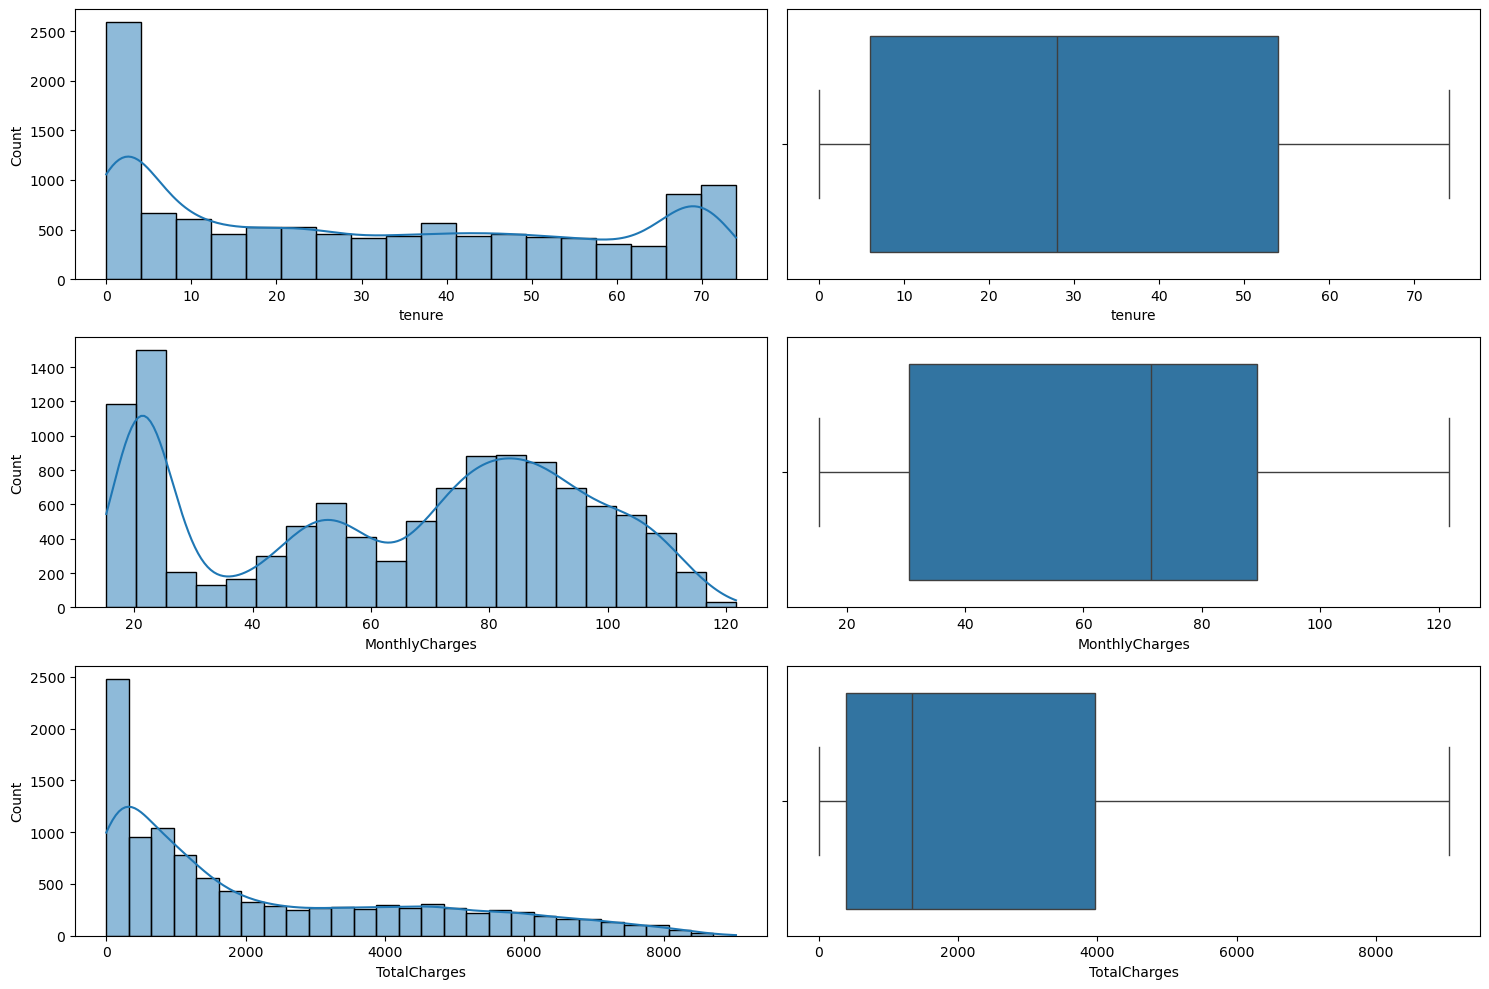

In [32]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols):
    plt.subplot(3,2,(i*2)+1)
    sns.histplot(df[col],kde=True)

    plt.subplot(3,2,(i*2)+2)
    sns.boxplot(data=df,x=col)

plt.tight_layout()
plt.show()

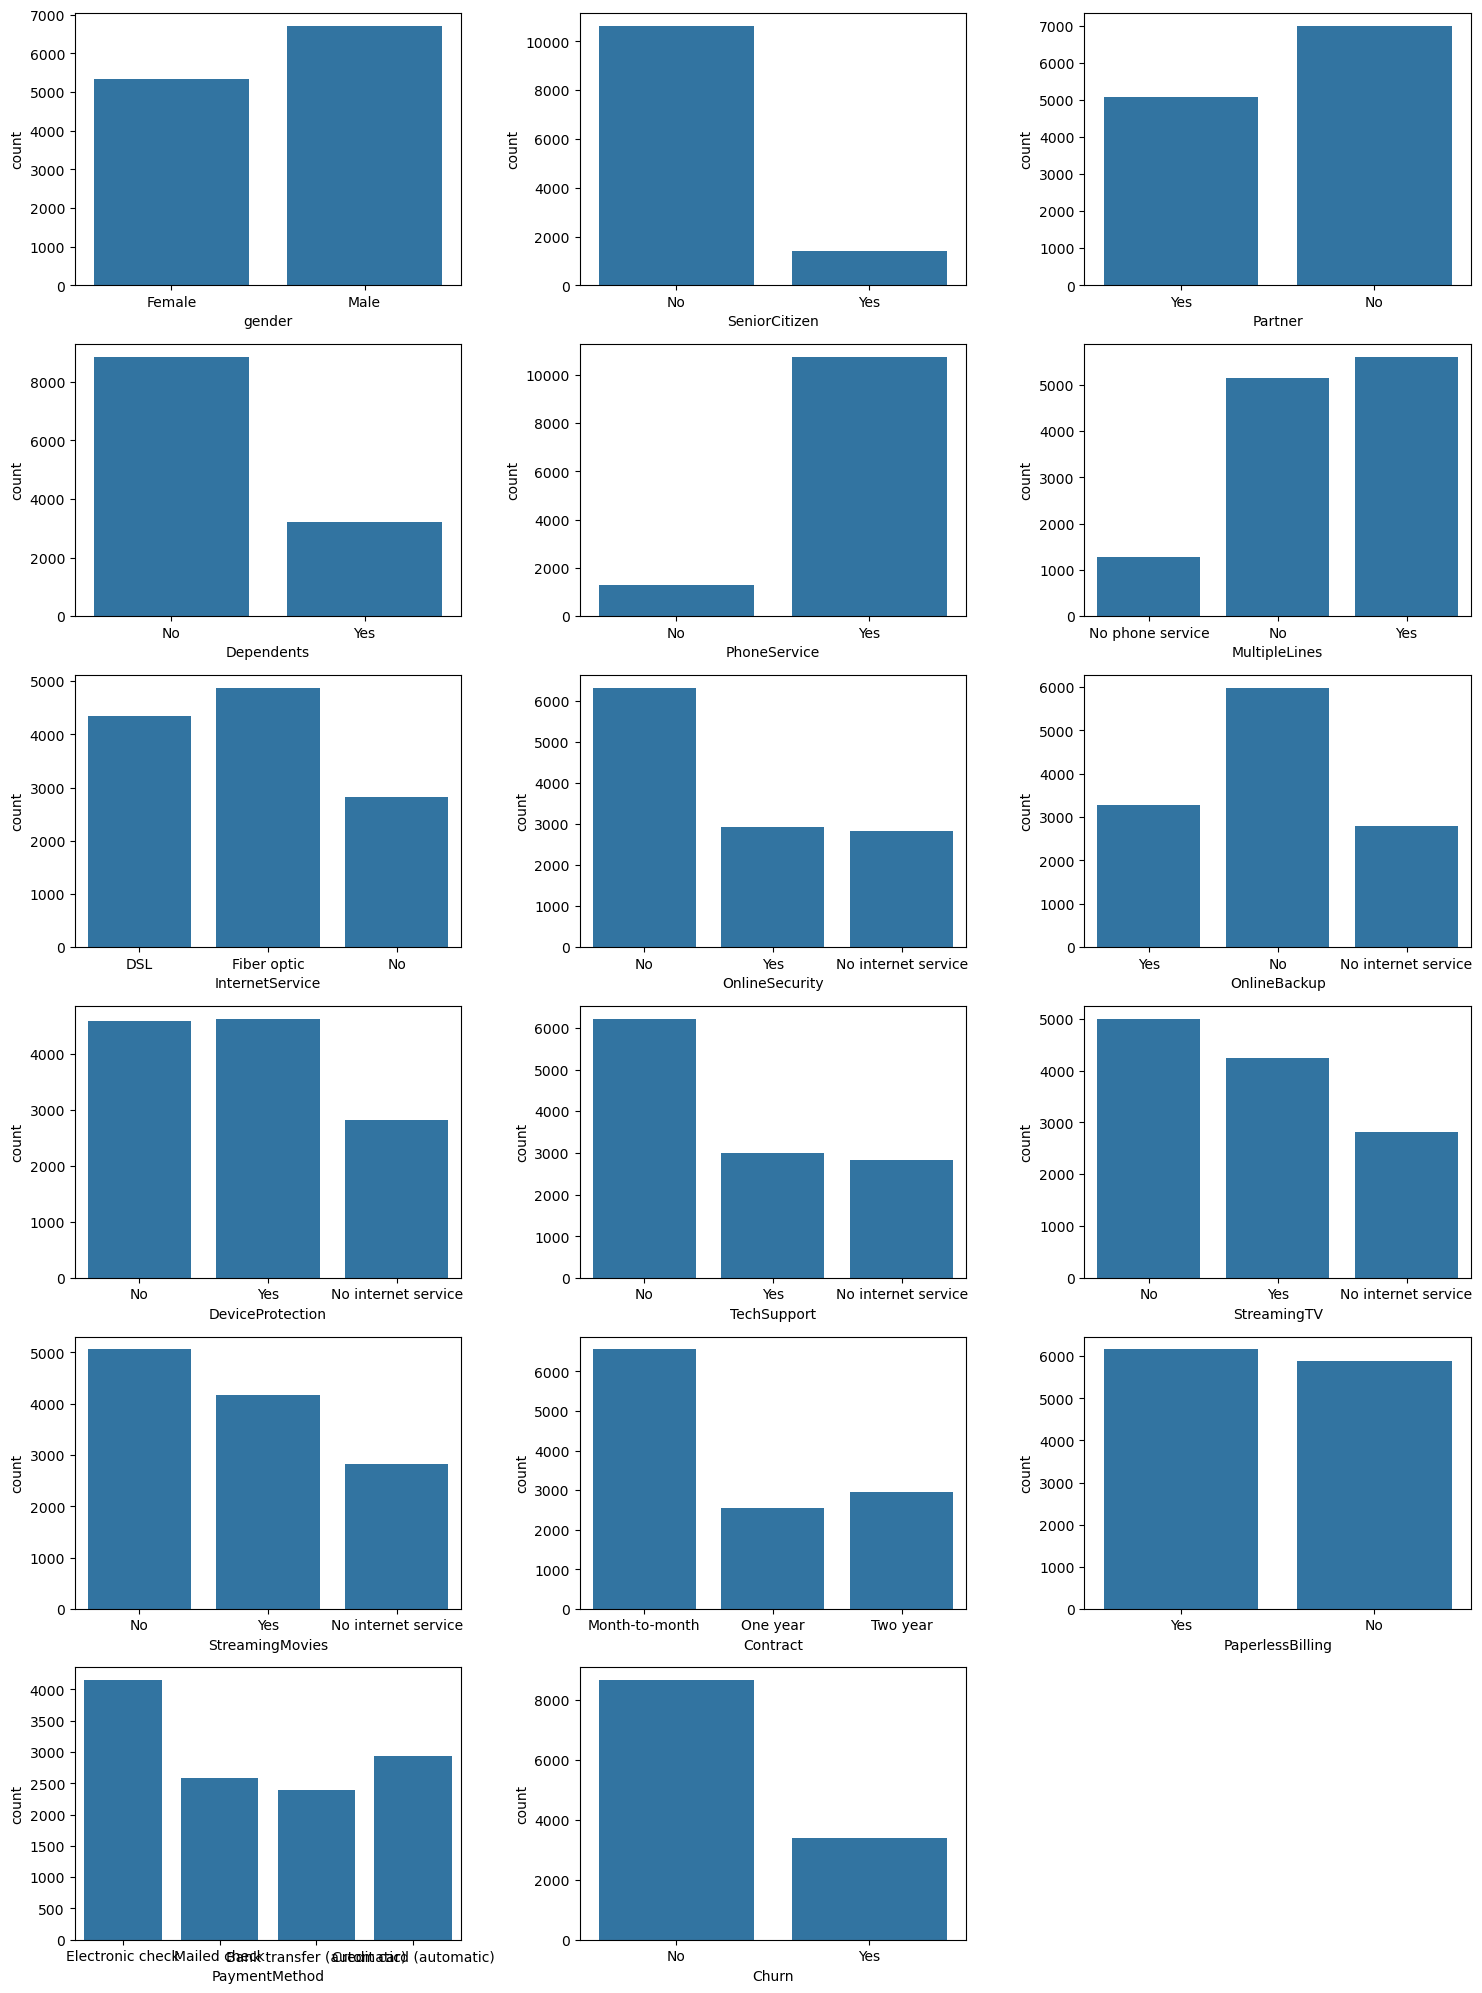

In [33]:
plt.figure(figsize=(15,20))
for i,col in enumerate(cat_cols):
    plt.subplot(6,3,i+1)
    sns.countplot(data=df,x=col)
plt.tight_layout()
plt.show()

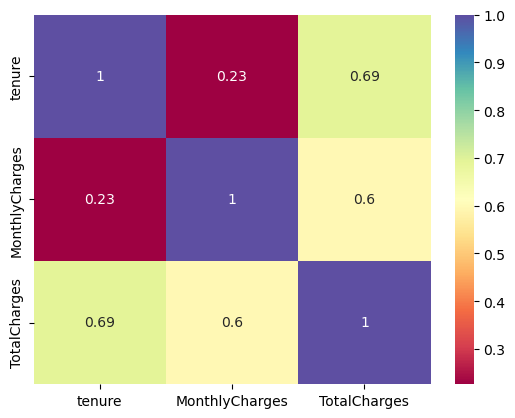

In [34]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Spectral')
plt.show()
            

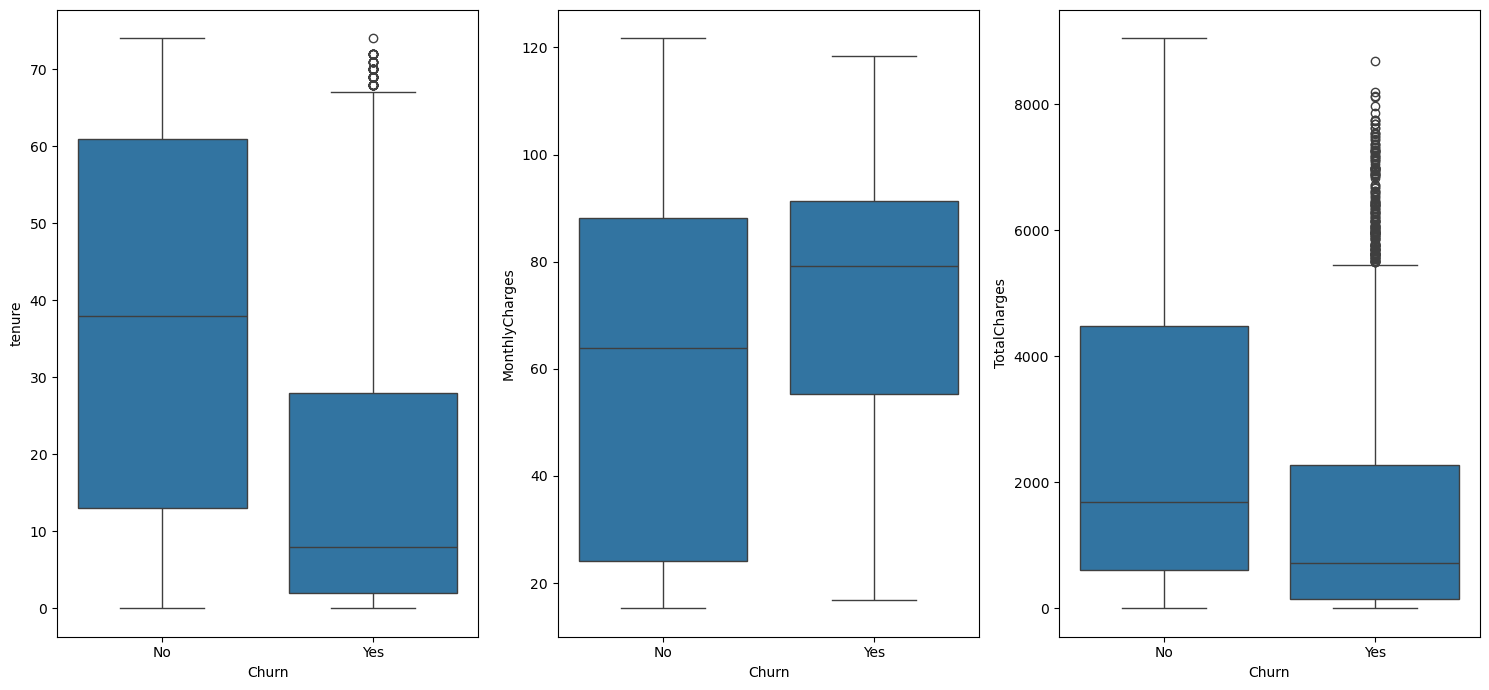

In [35]:
plt.figure(figsize=(15,7))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x='Churn',y=col)
plt.tight_layout()
plt.show()
    

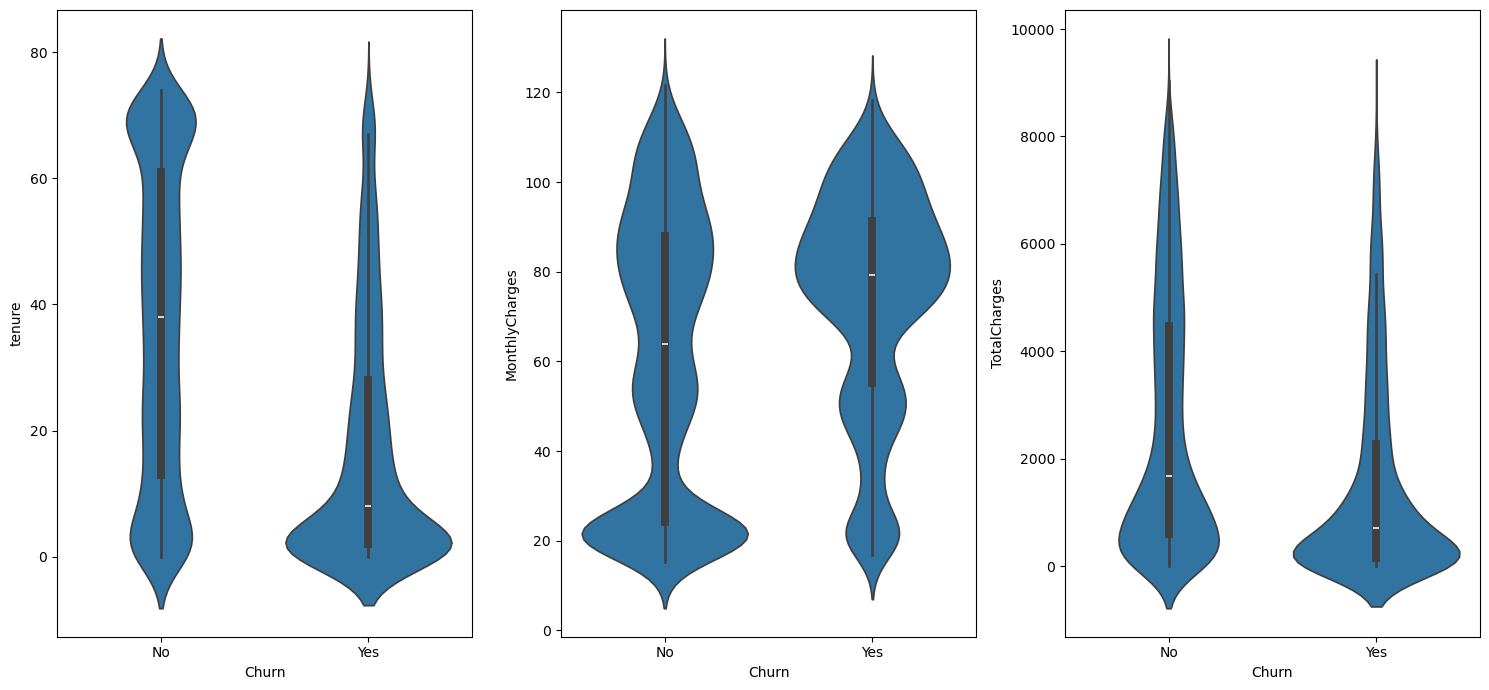

In [36]:
plt.figure(figsize=(15,7))
for i,col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.violinplot(data=df,x='Churn',y=col)
plt.tight_layout()
plt.show()

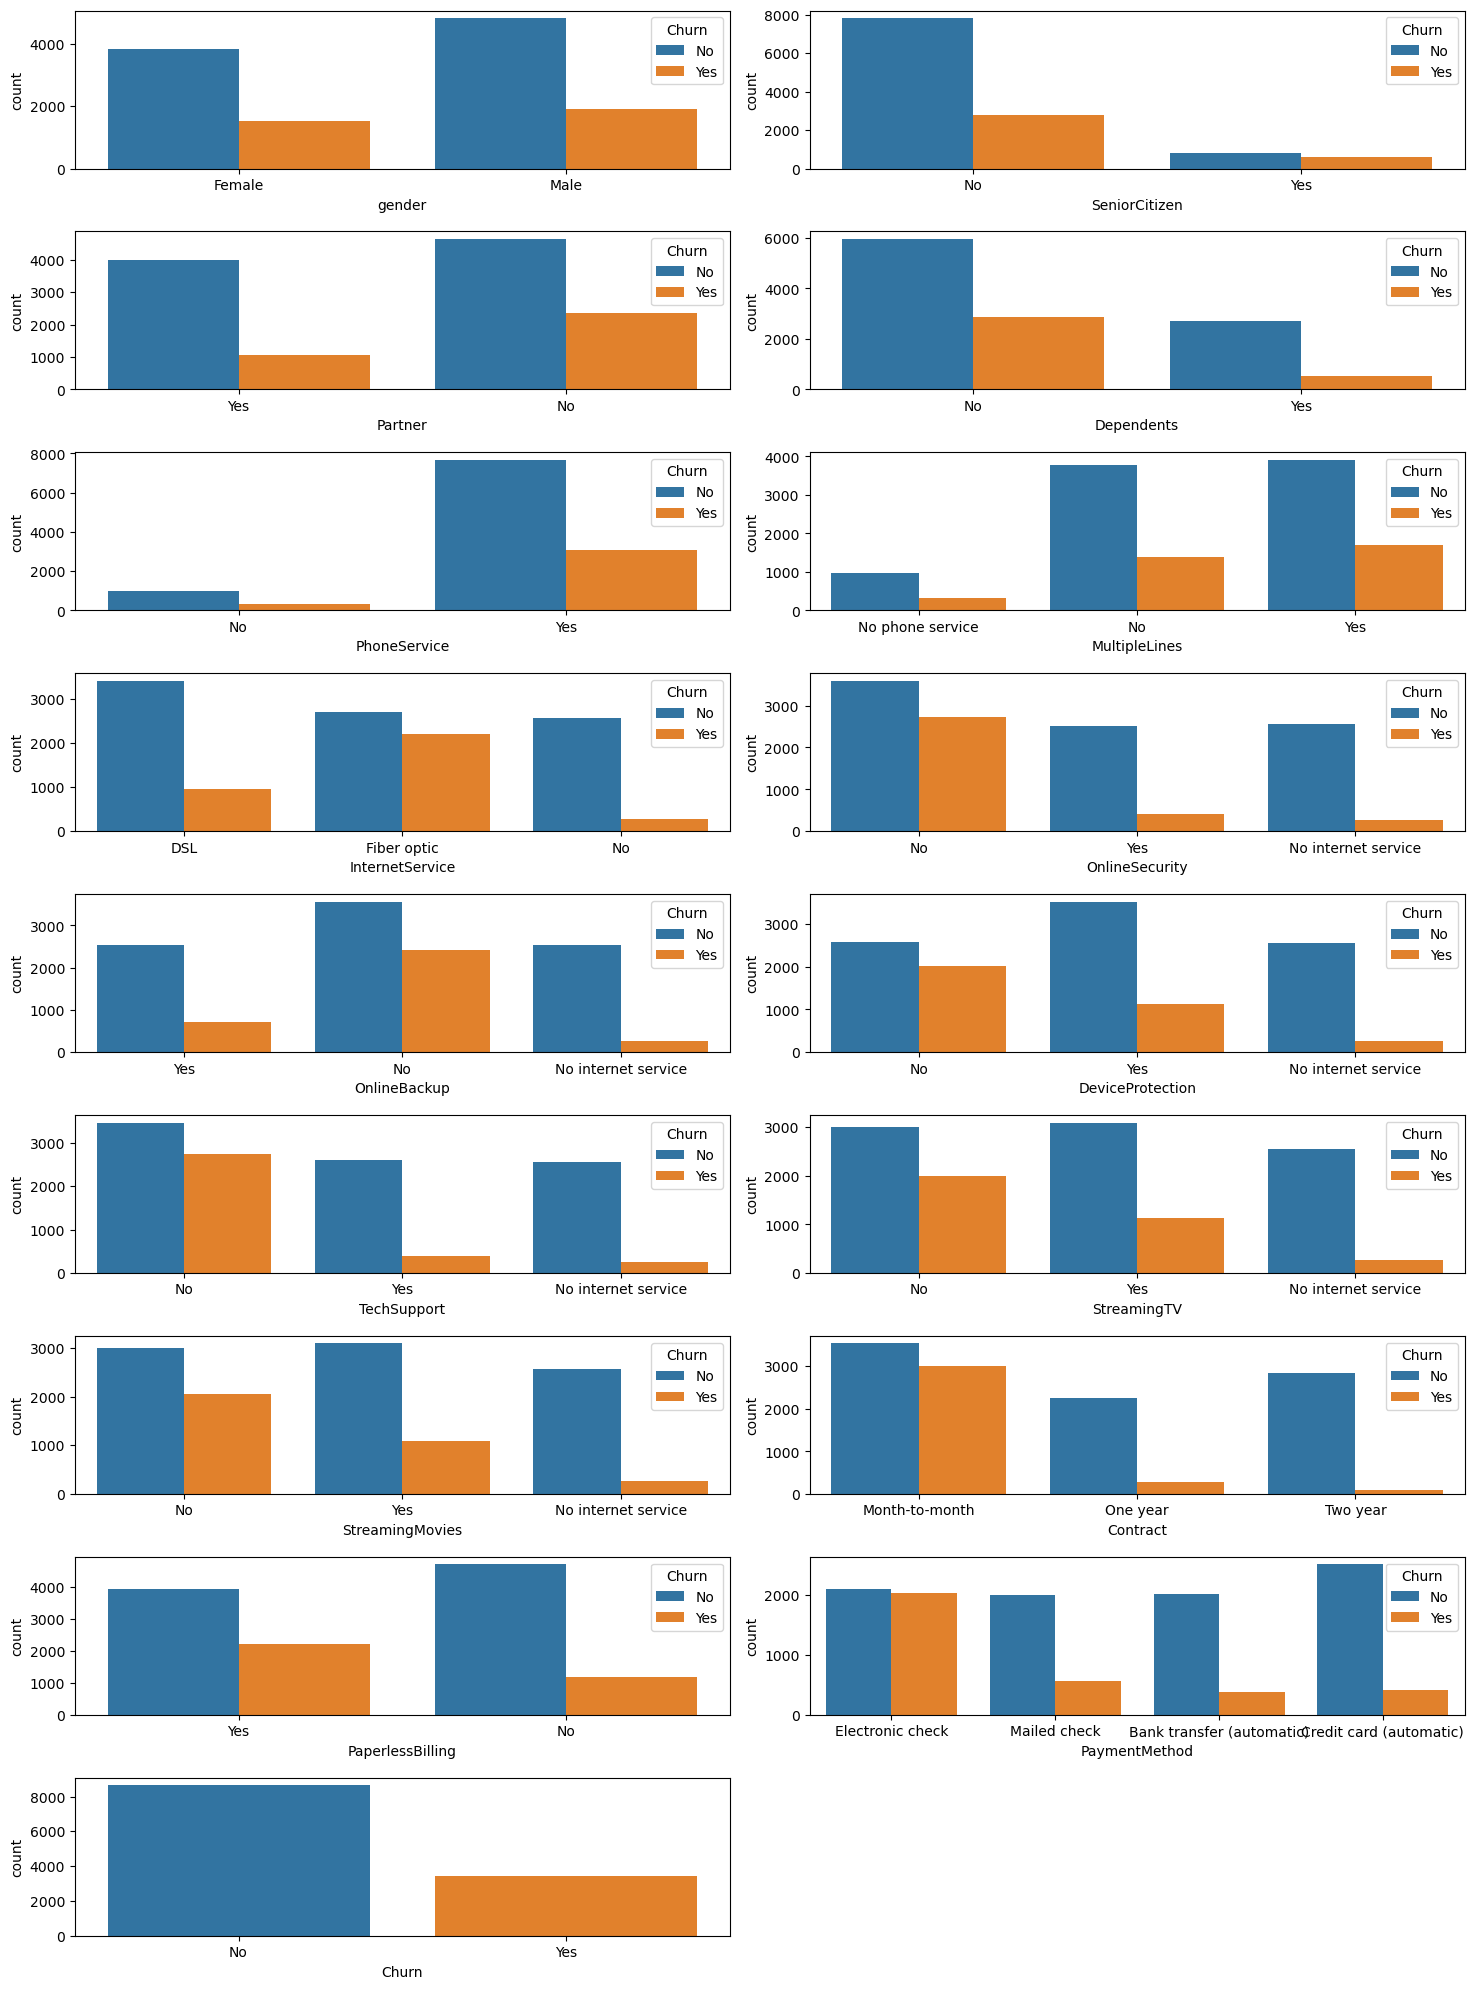

In [37]:
plt.figure(figsize=(15,20))
for i,col in enumerate(cat_cols):
    plt.subplot(9,2,i+1)
    sns.countplot(data=df,x=col,hue='Churn')
plt.tight_layout()
plt.show()

<Figure size 1500x2000 with 0 Axes>

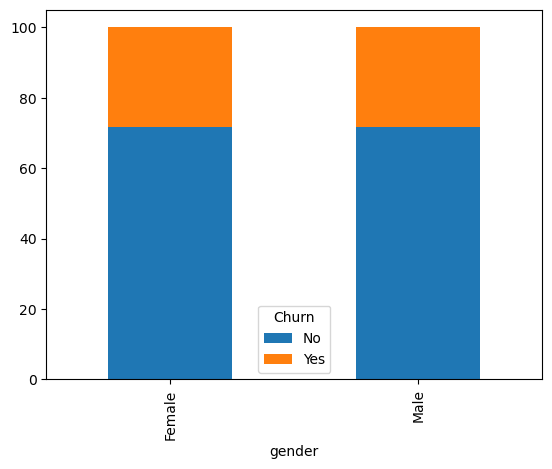

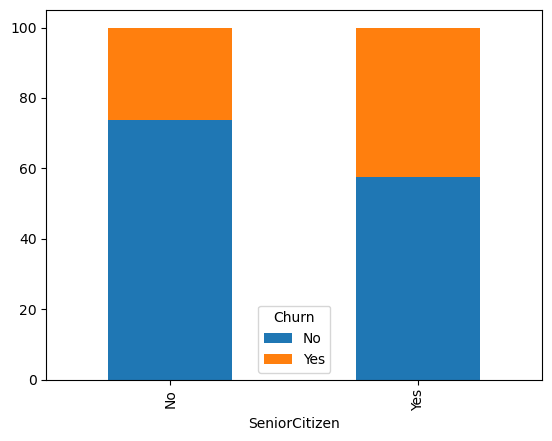

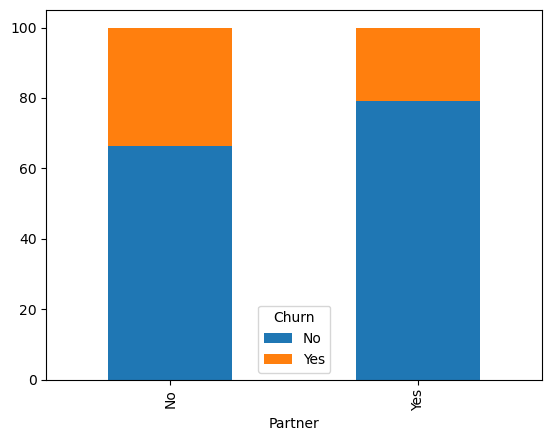

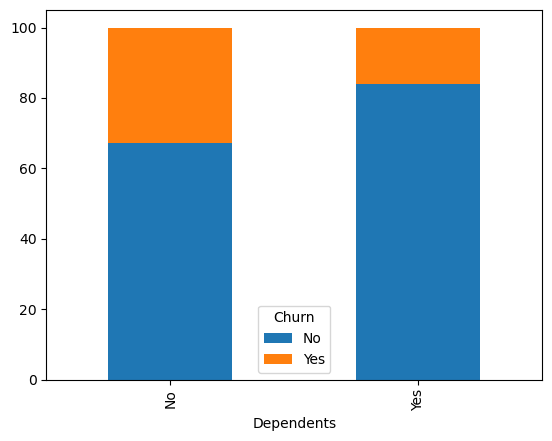

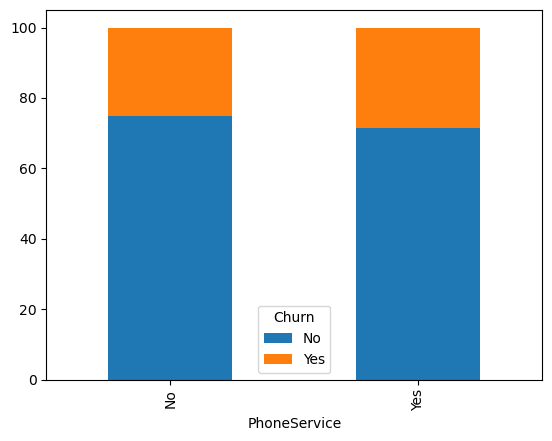

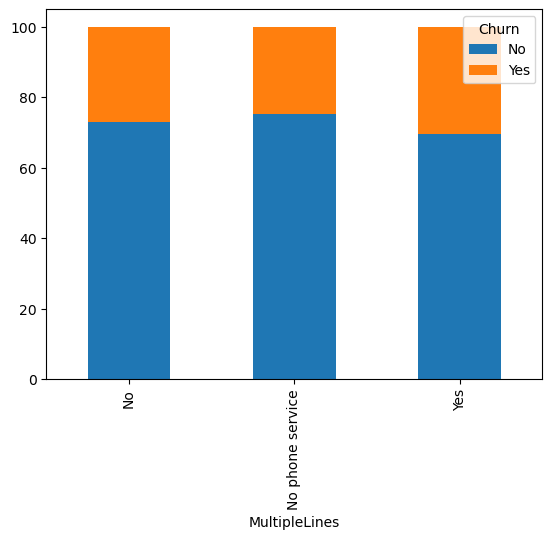

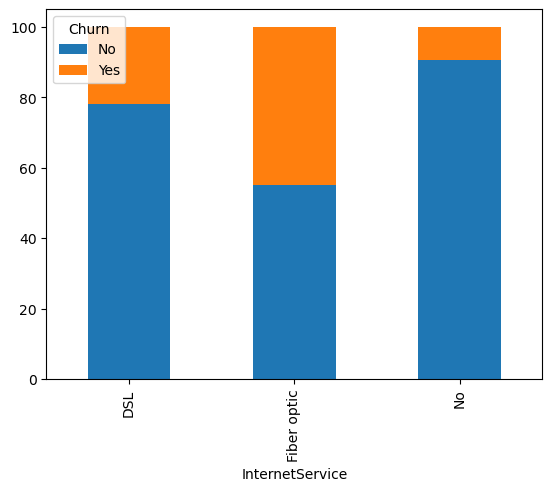

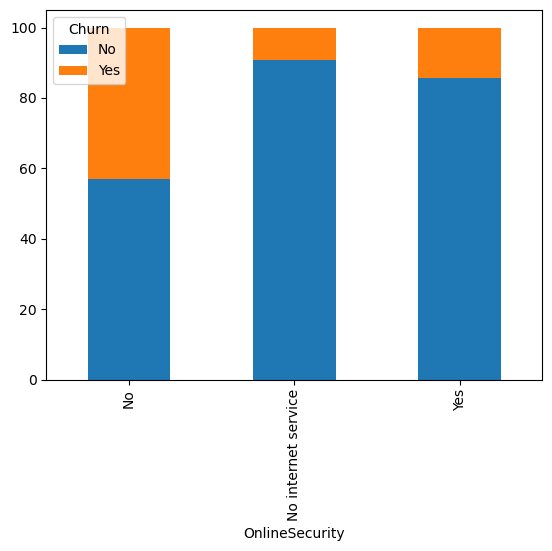

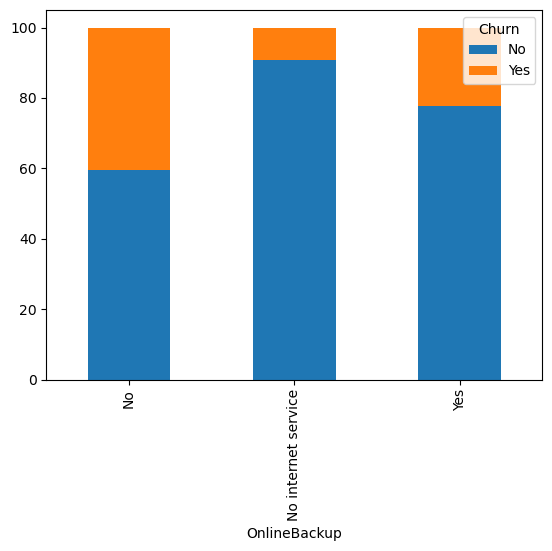

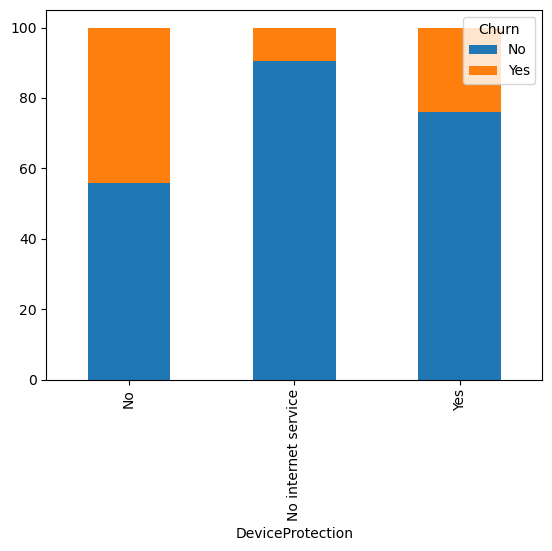

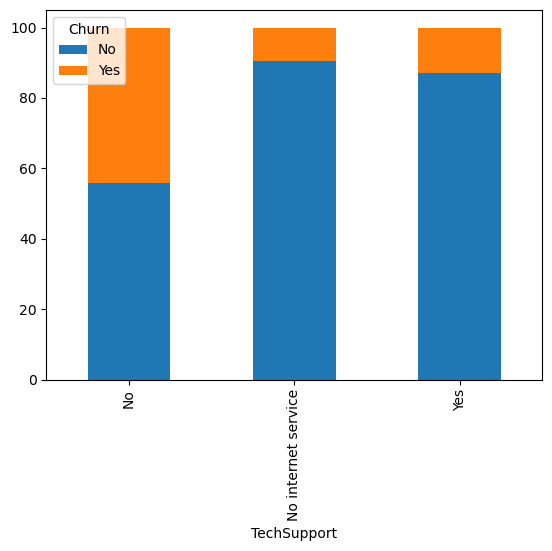

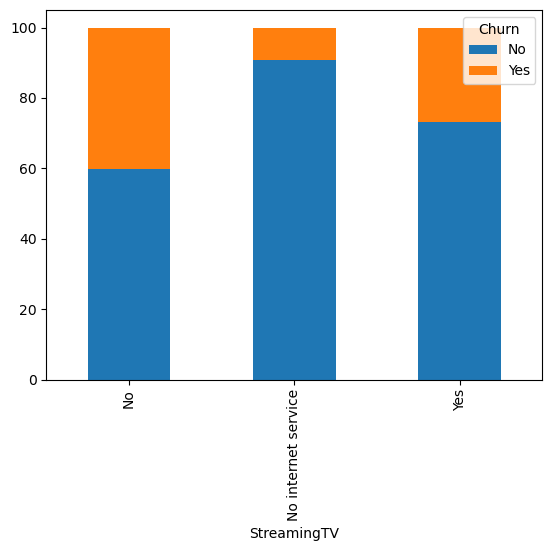

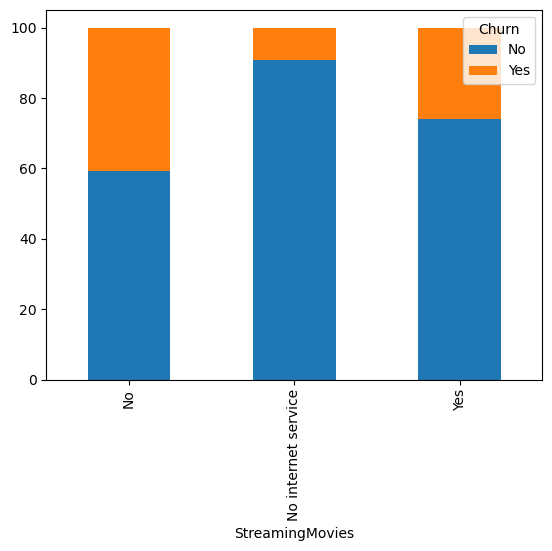

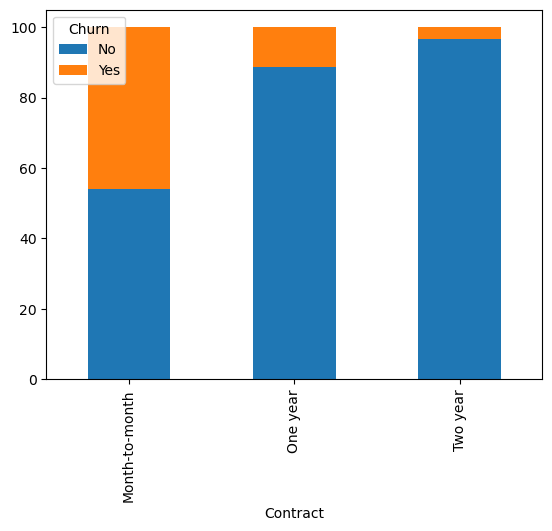

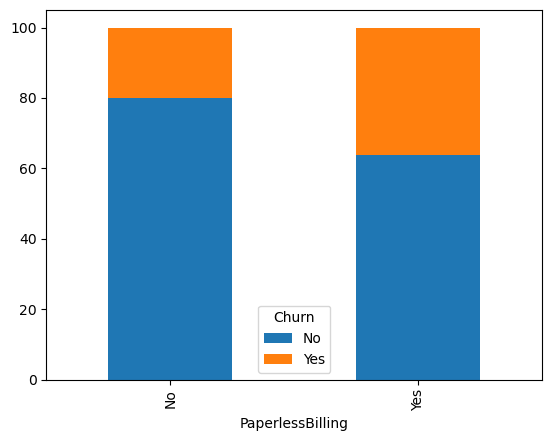

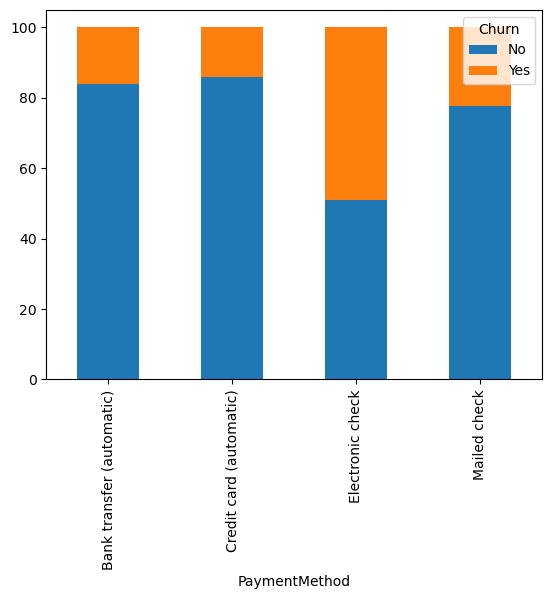

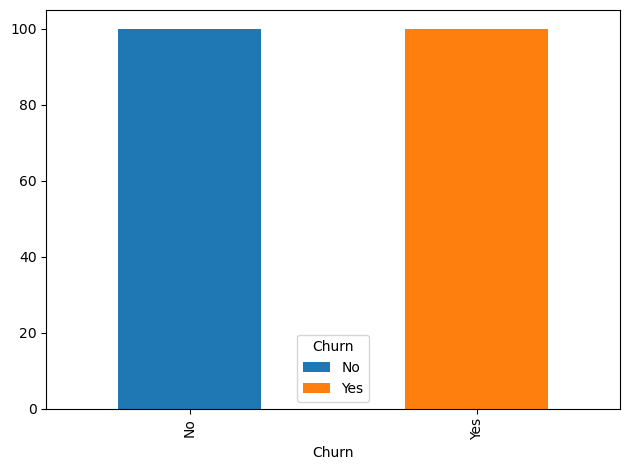

In [38]:
plt.figure(figsize=(15,20))
for i,col in enumerate(cat_cols):
    #plt.subplot(17,1,i+1)
    ct=pd.crosstab(df[col],df['Churn'],normalize='index')*100
    ct.plot(kind='bar',stacked=True)

plt.tight_layout()
plt.show()

In [39]:
cat_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [40]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

<Axes: xlabel='InternetService', ylabel='MonthlyCharges'>

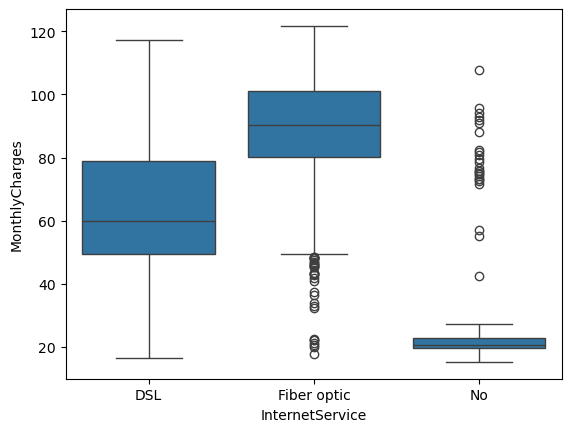

In [41]:
sns.boxplot(data=df,x='InternetService',y='MonthlyCharges')

In [42]:
cols=['OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']



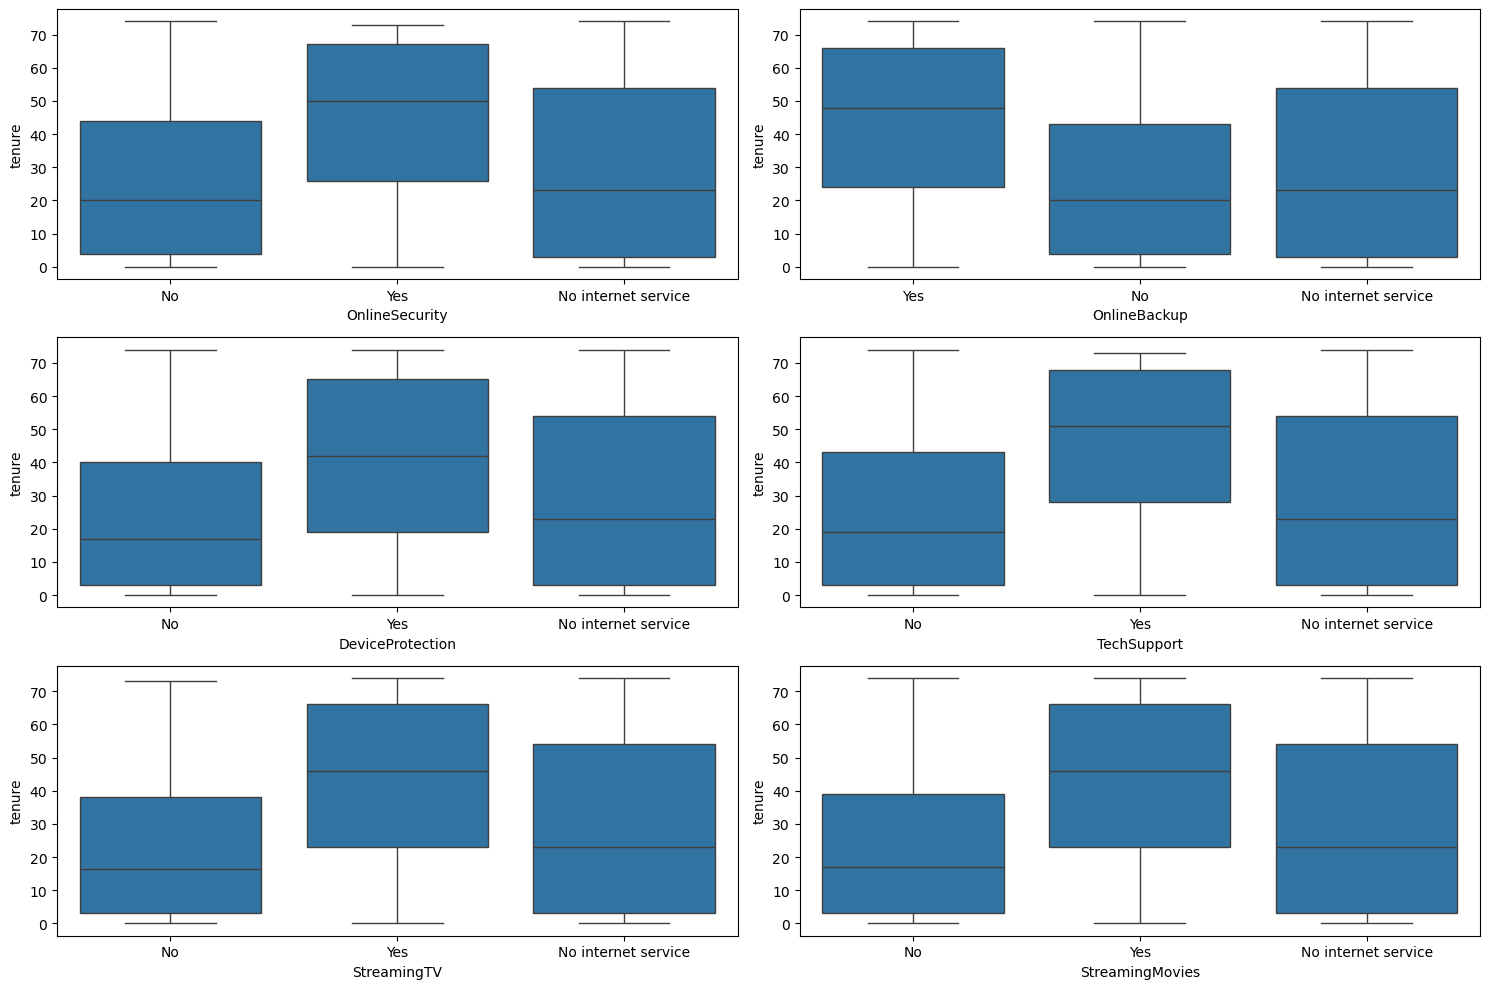

In [43]:
plt.figure(figsize=(15,10))
for i,col in enumerate(cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=df,x=col,y='tenure')
plt.tight_layout()
plt.show()

In [44]:
cols_new=['Contract',
 'PaperlessBilling',
 'PaymentMethod']



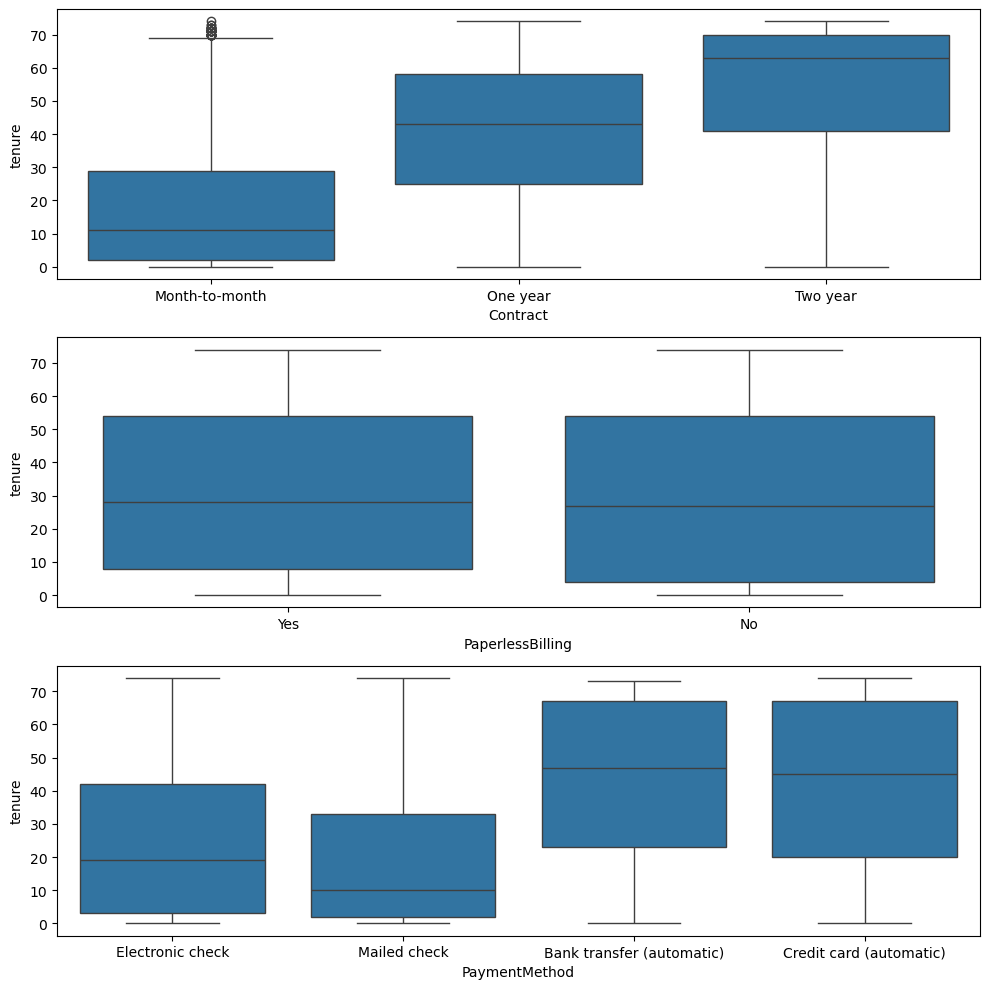

In [45]:
plt.figure(figsize=(10,10))
for i,col in enumerate(cols_new):
    plt.subplot(3,1,i+1)
    sns.boxplot(data=df,x=col,y='tenure')
plt.tight_layout()
plt.show()

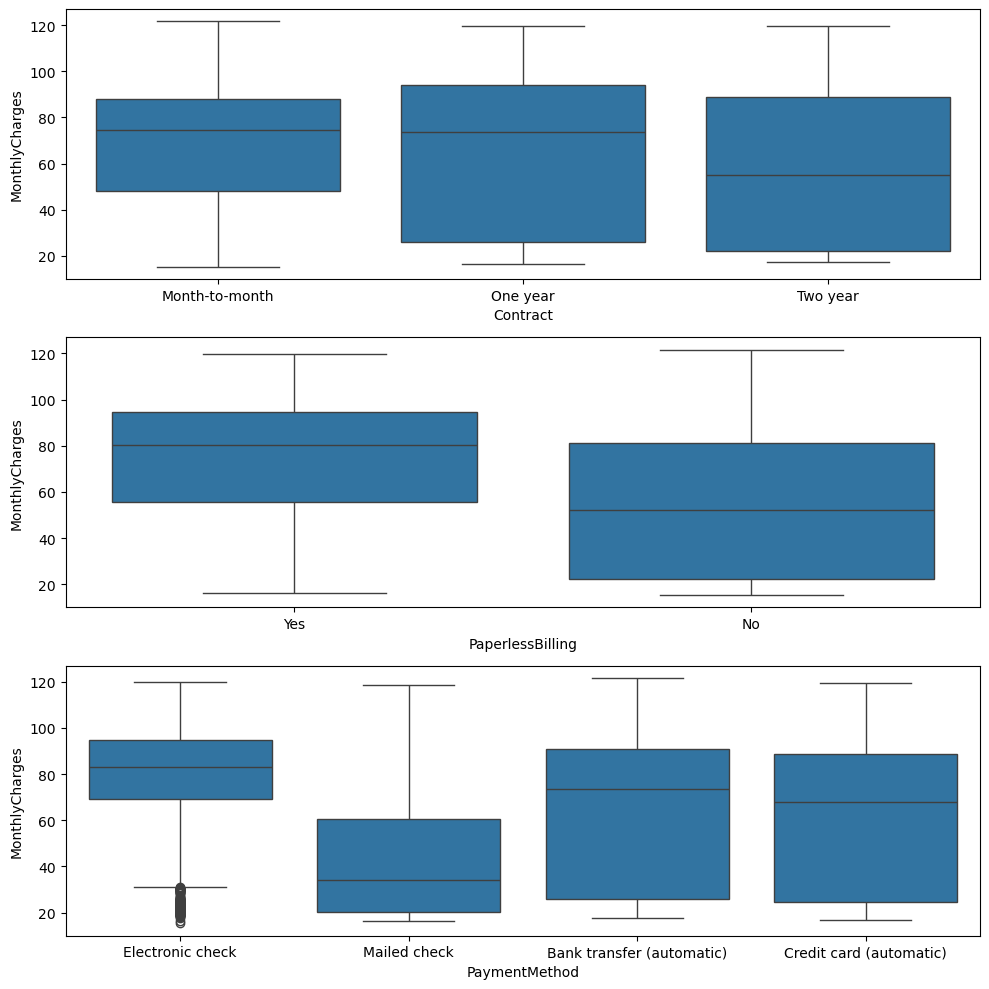

In [46]:
plt.figure(figsize=(10,10))
for i,col in enumerate(cols_new):
    plt.subplot(3,1,i+1)
    sns.boxplot(data=df,x=col,y='MonthlyCharges')
plt.tight_layout()
plt.show()

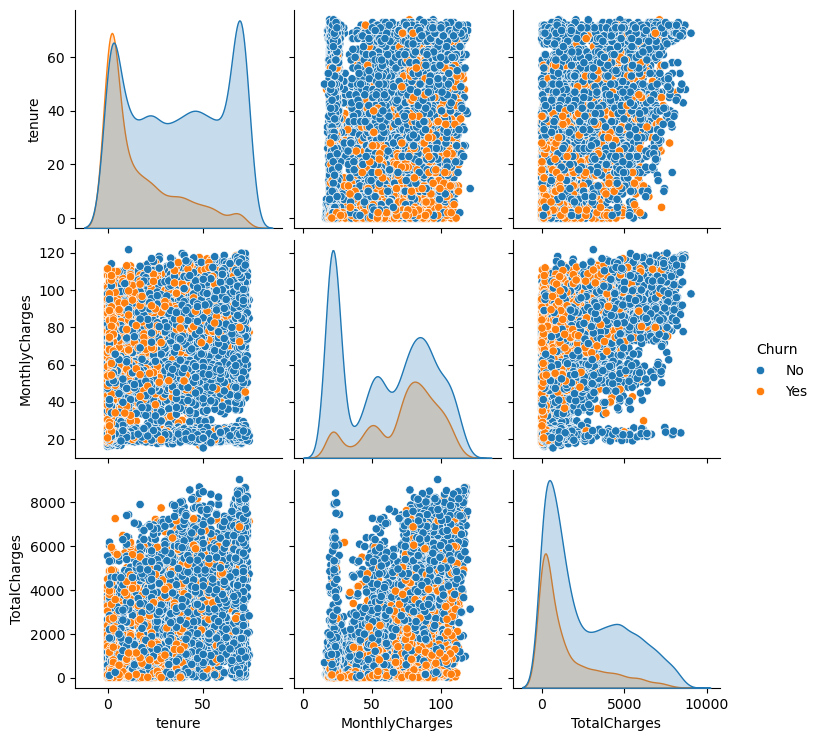

In [47]:
sns.pairplot(data=df,hue='Churn')

In [48]:
df.duplicated().sum()

np.int64(27)

In [49]:
df.drop_duplicates(keep='first',inplace=True)

In [50]:
df.shape

(12028, 20)

In [51]:
df.isnull().sum()

gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure               602
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges       483
TotalCharges        1374
Churn                  0
dtype: int64

In [52]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     71.782507
Yes    28.217493
Name: proportion, dtype: float64

In [53]:
df['Churn']=df['Churn'].replace({'No':0,'Yes':1})

/var/folders/l6/s1sx7qqx0mn47rs3_x440lb00000gn/T/ipykernel_38020/3615912532.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn']=df['Churn'].replace({'No':0,'Yes':1})


In [54]:
df['Churn'].value_counts(normalize=True)*100

Churn
0    71.782507
1    28.217493
Name: proportion, dtype: float64

In [55]:
X=df.drop('Churn',axis=1)
y=df['Churn']

X=pd.get_dummies(X,drop_first=True,dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

In [56]:
imputer=SimpleImputer(strategy='median')
X_train[num_cols]=imputer.fit_transform(X_train[num_cols])
X_test[num_cols]=imputer.transform(X_test[num_cols])

In [57]:
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [58]:
def get_performance_measure(predictor,target,model,name):
    y_pred=model.predict(predictor)
    accuracy=accuracy_score(target,y_pred)
    recall=recall_score(target,y_pred)
    precision=precision_score(target,y_pred)
    f1=f1_score(target,y_pred)
    #df_score=pd.DataFrame({'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1_score':f1},index=[0])
    #print(df_score)
    print(name,'\n')
    print('Accuracy: ',accuracy)
    print('\n Classification Report\n',classification_report(target,y_pred))
    print('-'*50)
    

In [59]:
def get_confusion_matrix(predictor,target,model):
    y_pred=model.predict(predictor)
    cm=confusion_matrix(target,y_pred)
    sns.heatmap(cm,annot=True,fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [60]:
lr_model=LogisticRegression(random_state=42,max_iter=2000,class_weight='balanced')
lr_model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [61]:
get_performance_measure(X_train,y_train,lr_model,'LogisticRegressionModel')

LogisticRegressionModel 

Accuracy:  0.7598289583085878

 Classification Report
               precision    recall  f1-score   support

           0       0.90      0.74      0.82      6043
           1       0.55      0.80      0.65      2376

    accuracy                           0.76      8419
   macro avg       0.73      0.77      0.73      8419
weighted avg       0.80      0.76      0.77      8419

--------------------------------------------------


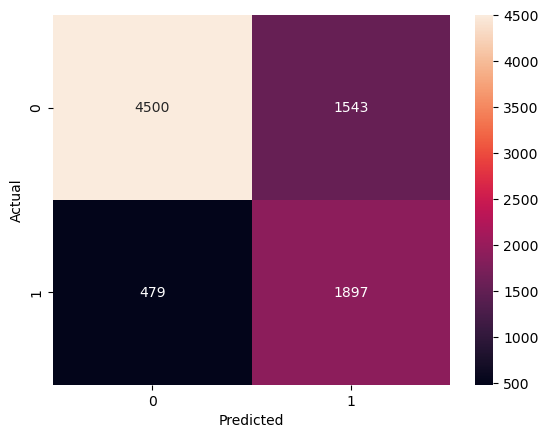

In [62]:
get_confusion_matrix(X_train,y_train,lr_model)

In [63]:
get_performance_measure(X_test,y_test,lr_model,'LogisticRegressionModel')

LogisticRegressionModel 

Accuracy:  0.7617068440011083

 Classification Report
               precision    recall  f1-score   support

           0       0.90      0.75      0.82      2591
           1       0.55      0.80      0.65      1018

    accuracy                           0.76      3609
   macro avg       0.73      0.77      0.74      3609
weighted avg       0.81      0.76      0.77      3609

--------------------------------------------------


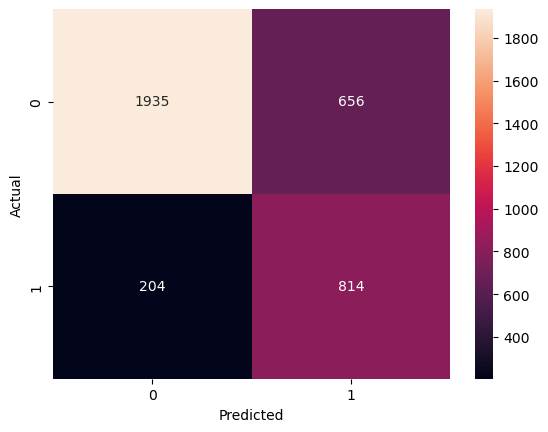

In [64]:
get_confusion_matrix(X_test,y_test,lr_model)

In [65]:

models=[]

models.append(('DecisionTreeModel',DecisionTreeClassifier(class_weight='balanced',random_state=42)))
models.append(('RandomForestModel',RandomForestClassifier(class_weight='balanced',random_state=42)))
models.append(('BaggingModel',BaggingClassifier(random_state=42)))
models.append(('AdaBoostModel',AdaBoostClassifier(random_state=42)))
models.append(('GradientBoostModel',GradientBoostingClassifier(random_state=42)))
models.append(('XGBModel',XGBClassifier(random_state=42)))

print('Training performance:\n')
print('-'*50)
for name,model in models:
    model.fit(X_train,y_train)   
    get_performance_measure(X_train,y_train,model,name)

Training performance:

--------------------------------------------------
DecisionTreeModel 

Accuracy:  0.9994061052381518

 Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6043
           1       1.00      1.00      1.00      2376

    accuracy                           1.00      8419
   macro avg       1.00      1.00      1.00      8419
weighted avg       1.00      1.00      1.00      8419

--------------------------------------------------
RandomForestModel 

Accuracy:  0.9994061052381518

 Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6043
           1       1.00      1.00      1.00      2376

    accuracy                           1.00      8419
   macro avg       1.00      1.00      1.00      8419
weighted avg       1.00      1.00      1.00      8419

--------------------------------------------------
BaggingModel 

Accur

In [66]:
models=[]

models.append(('DecisionTreeModel',DecisionTreeClassifier(class_weight='balanced',random_state=42)))
models.append(('RandomForestModel',RandomForestClassifier(class_weight='balanced',random_state=42)))
models.append(('BaggingModel',BaggingClassifier(random_state=42)))
models.append(('AdaBoostModel',AdaBoostClassifier(random_state=42)))
models.append(('GradientBoostModel',GradientBoostingClassifier(random_state=42)))
models.append(('XGBModel',XGBClassifier(random_state=42)))

print('Testing performance:\n')
print('-'*50)
for name,model in models:
    model.fit(X_train,y_train)   
    get_performance_measure(X_test,y_test,model,name)

Testing performance:

--------------------------------------------------
DecisionTreeModel 

Accuracy:  0.7342754225547243

 Classification Report
               precision    recall  f1-score   support

           0       0.81      0.83      0.82      2591
           1       0.53      0.50      0.51      1018

    accuracy                           0.73      3609
   macro avg       0.67      0.66      0.67      3609
weighted avg       0.73      0.73      0.73      3609

--------------------------------------------------
RandomForestModel 

Accuracy:  0.8024383485730119

 Classification Report
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      2591
           1       0.70      0.53      0.60      1018

    accuracy                           0.80      3609
   macro avg       0.76      0.72      0.74      3609
weighted avg       0.79      0.80      0.79      3609

--------------------------------------------------
BaggingModel 

Accura

In [74]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
model=XGBClassifier(random_state=42,eval_metric='logloss')
parameters = {
    "max_depth": np.arange(4,6,1),
    "n_estimators": np.arange(150,200,10),
    "subsample":[0.5,0.7,0.9,1],
    "learning_rate":[0.01,0.1,0.2,0.05],
    "gamma":[0,1,3],
    "colsample_bytree":[0.5,0.7,0.9,1],
    "colsample_bylevel":[0.5,0.7,0.9,1],
    'scale_pos_weight': np.arange(2.5,4)
}
random_obj=RandomizedSearchCV(model,parameters,cv=5,scoring='recall',n_iter=200,n_jobs=-1,verbose=0)
random_obj.fit(X_train,y_train)

xgb_tuned=random_obj.best_estimator_
xgb_tuned.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.5, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(4), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(160), n_jobs=None,
              num_parallel_tree=None, ...)

In [75]:
get_performance_measure(X_train,y_train,xgb_tuned,'XGB_Tuned_Model')

XGB_Tuned_Model 

Accuracy:  0.7029338401235301

 Classification Report
               precision    recall  f1-score   support

           0       0.94      0.63      0.75      6043
           1       0.49      0.89      0.63      2376

    accuracy                           0.70      8419
   macro avg       0.71      0.76      0.69      8419
weighted avg       0.81      0.70      0.72      8419

--------------------------------------------------


In [76]:
get_performance_measure(X_test,y_test,xgb_tuned,'XGB_Tuned_Model')

XGB_Tuned_Model 

Accuracy:  0.713771127736215

 Classification Report
               precision    recall  f1-score   support

           0       0.94      0.65      0.76      2591
           1       0.50      0.89      0.64      1018

    accuracy                           0.71      3609
   macro avg       0.72      0.77      0.70      3609
weighted avg       0.81      0.71      0.73      3609

--------------------------------------------------


In [77]:
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    #Let's try different max_depth for base_estimator
    "estimator":[DecisionTreeClassifier(max_depth=1, random_state=1),DecisionTreeClassifier(max_depth=2, random_state=1),DecisionTreeClassifier(max_depth=3, random_state=1)],
    "n_estimators": np.arange(10,110,10),
    "learning_rate":np.arange(0.1,2,0.1)
}


# Run the grid search
grid_obj = RandomizedSearchCV(abc_tuned, parameters,scoring='recall',n_jobs=-1,n_iter=50,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=np.float64(1.5), n_estimators=np.int64(100),
                   random_state=1)

In [78]:
get_performance_measure(X_train,y_train,abc_tuned,'AdaBoost_Tuned_Model')

AdaBoost_Tuned_Model 

Accuracy:  0.808884665637249

 Classification Report
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      6043
           1       0.68      0.60      0.64      2376

    accuracy                           0.81      8419
   macro avg       0.77      0.75      0.76      8419
weighted avg       0.80      0.81      0.81      8419

--------------------------------------------------


In [79]:
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {
    "n_estimators": [100,150,200,250],
    "subsample":[0.8,0.9,1],
    "max_features":[0.7,0.8,0.9,1]
}



# Run the grid search
grid_obj = RandomizedSearchCV(gbc_tuned, parameters, scoring='recall',n_iter=50,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 48 is smaller than n_iter=50. Running 48 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.8, n_estimators=150, random_state=1,
                           subsample=0.9)

In [80]:
get_performance_measure(X_train,y_train,gbc_tuned,'GradientBoosting_Tuned_Model')

GradientBoosting_Tuned_Model 

Accuracy:  0.8289583085877182

 Classification Report
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      6043
           1       0.73      0.62      0.67      2376

    accuracy                           0.83      8419
   macro avg       0.80      0.77      0.78      8419
weighted avg       0.82      0.83      0.82      8419

--------------------------------------------------


In [81]:
get_performance_measure(X_test,y_test,gbc_tuned,'GradientBoosting_Tuned_Model')

GradientBoosting_Tuned_Model 

Accuracy:  0.802161263507897

 Classification Report
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      2591
           1       0.68      0.56      0.61      1018

    accuracy                           0.80      3609
   macro avg       0.76      0.73      0.74      3609
weighted avg       0.79      0.80      0.80      3609

--------------------------------------------------


Exception ignored in: <function ResourceTracker.__del__ at 0x1070b5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1070a1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107efdb20>
Traceback (most recent call last

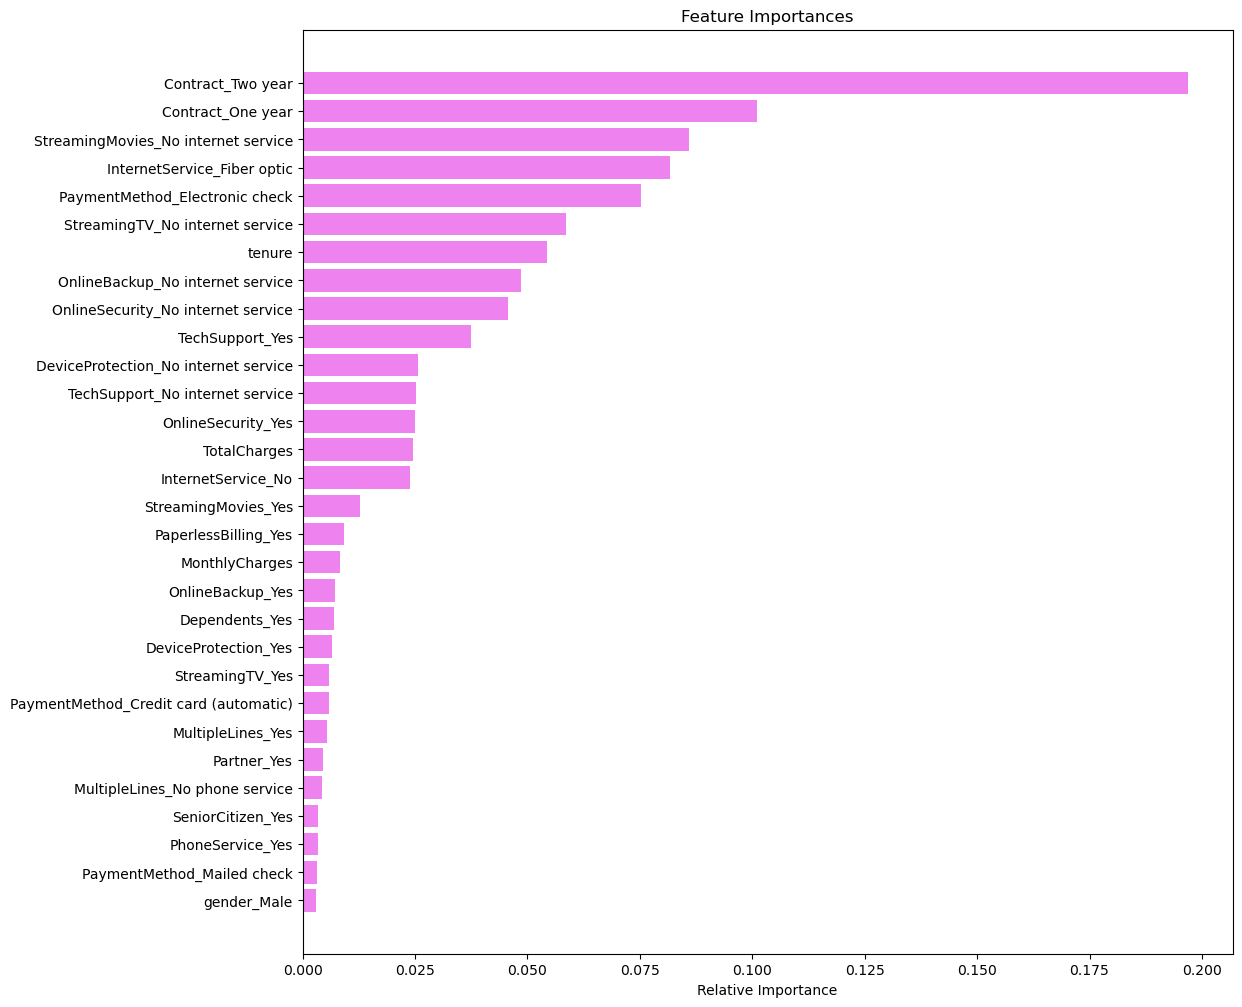

In [82]:
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()